# 17 — SJM × crowding de-risk variant: AI-calibrated limits, deterministic application

**Goal:** reduce the Factor PIT line's max drawdown at little return cost. Design, per the user's brief:

1. **SJM regimes** — the Sparse Jump Model (Shu & Mulvey 2024 / Nystrup et al., ported from facdrone) fit **walk-forward** on the world-equity sleeve: refit at every monthly rebalance using only strictly-prior data (the facdrone look-ahead incident is the cautionary tale; a regime model refit on full history is recall by another name).
2. **Crowding signal** — return-space concentration proxies over the **full 112-ETF cross-section**: the Kritzman **absorption ratio** (share of variance in the top eigenvectors) and **financial turbulence** (Mahalanobis distance). PIT expanding-quantile buckets.
3. **AI determines the macro limits** — one *offline* LLM call (NIM `gpt-oss-20b`, anonymized prompt, dev-window statistics only) proposes a **cap table**: max risky exposure per (SJM regime × crowding bucket). Persisted as a versioned artifact.
4. **Deterministic application** — at each monthly rebalance a pure function maps (regime, bucket) → cap; the book holds `cap × FactorPIT + (1−cap) × BIL`. **No AI at runtime.**
5. **/loop** — the `factor_loop.run_loop` engine mutates the deterministic knobs (SJM λ, signal choice, window, cap scaling) on a **dev window (2019-01→2024-06)** only; keep iff Calmar improves, CAGR cost ≤ 1pp, max-DD not worse, **and it beats the dumb correlation-overlay control**. The **holdout (2024-07→2026-06) is untouched** until the final table.

De-risk only — caps ≤ 1, never leverage, never winner-picking (the facdrone SJM evidence: regime *return-seeking* tilts were net-harmful; regime *de-risking* is the defensible use).

In [1]:
%load_ext autoreload
%autoreload 2

import json, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import macro_framework as mf
from macro_framework import skill_metric as sk
from macro_framework.ssr import compute_ssr, newey_west_var
from macro_framework.jump_regime import JumpRegimeConfig, sjm_features, fit_labels_walk_forward, BULL, BEAR, NEUTRAL
from macro_framework.crowding import absorption_ratio, turbulence, crowding_bucket
from macro_framework.regime_overlay import derisk_cash_pin
import factor_loop as fl

pd.set_option("display.width", 220)
A = 252
BASKET = ["SWDA.L", "XLK", "IAU", "BIL"]
DEV_END = pd.Timestamp("2024-06-30")     # loop tunes ONLY on <= DEV_END; holdout untouched
RUN_ID = "sjm_crowding_v1"

DATA = Path.cwd().parent / "data"
REPORTS = Path.cwd().parent / "reports"
REPORTS.mkdir(exist_ok=True)

## 1. Load the Factor PIT line and the price cross-section

In [2]:
def active_span(v):
    moving = v[v.ne(v.iloc[0])]
    if moving.empty:
        return v
    fm = moving.index.min()
    prior = v.index[v.index < fm]
    return v.loc[(prior.max() if len(prior) else fm):]

factor_eq = active_span(pd.read_parquet(DATA / "factor_equity_ext2026.parquet")["value"])
factor_ret = factor_eq.pct_change().dropna()
print(f"Factor PIT: {factor_eq.index[0].date()} .. {factor_eq.index[-1].date()}")

# full 112-ETF cross-section for the crowding signal + the 4 sleeves + SPY
uni = mf.load_universe()["symbol"].tolist()
px_all = mf.get_prices(uni, start="2013-01-01", end="2026-07-01")
# the price frame is on the UNION calendar (LSE + US sessions), so every column has
# scattered NaNs; ffill within listings (cap 5 days) before differencing, else any
# NaN-in-window rule silently drops every column of the cross-section
ret_all = px_all.ffill(limit=5).pct_change()
ret_all = ret_all.loc[ret_all.notna().mean(axis=1) > 0.5]
px = px_all[[c for c in BASKET if c in px_all.columns]]
spy_ret = mf.get_prices("SPY", start="2013-01-01", end="2026-07-01")["SPY"].pct_change().rename("SPY")
bil_ret = px["BIL"].pct_change().reindex(factor_ret.index).fillna(0.0)
fac_ret4 = px[BASKET].pct_change()
print(f"cross-section: {ret_all.shape[1]} ETFs, {px_all.index[0].date()} .. {px_all.index[-1].date()}")

# monthly rebalance dates over the factor line's span
month_starts = factor_ret.resample("MS").first().index
reb_dates = pd.DatetimeIndex([factor_ret.index[factor_ret.index >= m][0]
                              for m in month_starts if (factor_ret.index >= m).any()])
print(f"rebalance dates: {len(reb_dates)} ({reb_dates[0].date()} .. {reb_dates[-1].date()})")

Factor PIT: 2019-01-02 .. 2026-06-30


cross-section: 112 ETFs, 2013-01-02 .. 2026-05-29
rebalance dates: 90 (2019-01-03 .. 2026-06-01)


## 2. SJM regimes — walk-forward on the world-equity sleeve

bull    65
bear    25


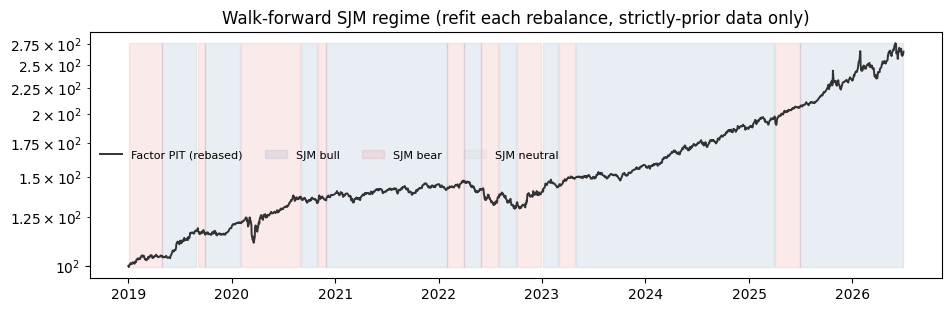

In [3]:
feat = sjm_features(px["SWDA.L"].dropna())
regime = fit_labels_walk_forward(feat, reb_dates, config=JumpRegimeConfig(), min_obs=504)
print(regime.value_counts().to_string())

fig, ax = plt.subplots(figsize=(11, 3.2))
eqn = factor_eq / factor_eq.iloc[0] * 100
ax.plot(eqn.index, eqn.values, color="#333", lw=1.4, label="Factor PIT (rebased)")
colors = {BULL: "#4e79a7", BEAR: "#e15759", NEUTRAL: "#bbbbbb"}
daily_regime = regime.reindex(factor_ret.index, method="ffill").fillna(NEUTRAL)
for lab in (BULL, BEAR, NEUTRAL):
    m = daily_regime == lab
    ax.fill_between(eqn.index, eqn.min(), eqn.max(), where=m.reindex(eqn.index, method="ffill").fillna(False),
                    color=colors[lab], alpha=0.12, label=f"SJM {lab}")
ax.set_yscale("log"); ax.legend(frameon=False, ncol=4, fontsize=8)
ax.set_title("Walk-forward SJM regime (refit each rebalance, strictly-prior data only)");

## 3. Crowding — absorption ratio & turbulence over the 112-ETF cross-section

We have no positioning data (COT/short interest/13F/flows), so **crowding is proxied in return space**: when a few factors absorb most cross-sectional variance (high absorption ratio) or the day's return vector is far from its trailing distribution (turbulence), the market is concentrated/fragile — the researched signature of crowded trades unwinding (Kritzman et al. 2011).

absorption ratio: 0.89..0.97

unconditional AR median 0.936 | turbulence median 92.0


,episode_start,trough,absorption,ar_pctile_pit,turbulence
0,2020-03-12,-11.0%,0.947134,1.000000,5299.345106
1,2020-04-01,-6.3%,0.974015,1.000000,550.923770
2,2022-06-13,-12.1%,0.941958,0.876543,244.582788
3,2022-08-11,-12.1%,0.944801,0.876682,80.426878
4,2022-08-17,-12.1%,0.944868,0.881379,48.162900
5,2022-11-17,-7.2%,0.951579,0.889130,85.882611
6,2022-12-05,-6.4%,0.953602,0.889706,101.158383
7,2022-12-15,-6.4%,0.954677,0.890086,136.734679
8,2022-12-22,-6.2%,0.954530,0.888172,161.760603
9,2022-12-28,-6.0%,0.953954,0.886168,74.492633


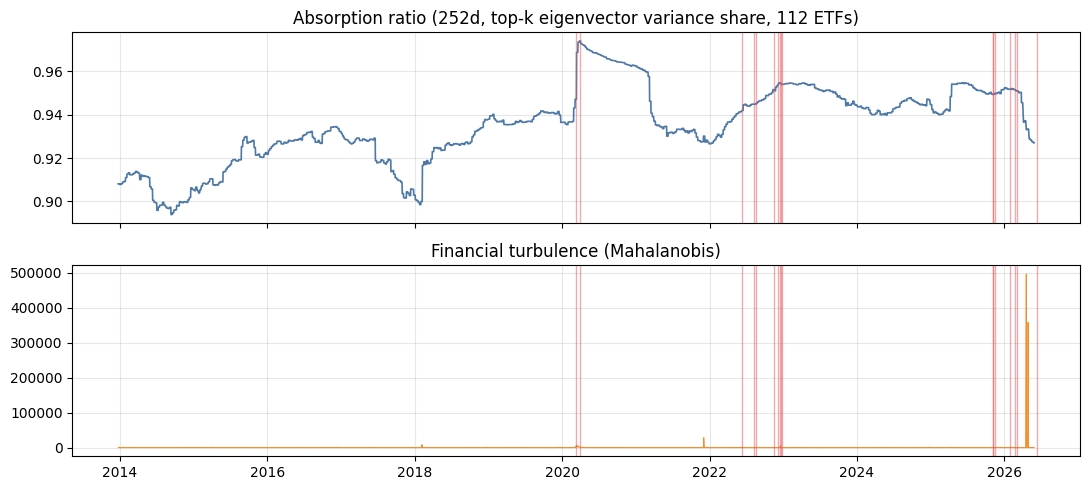

In [4]:
ar = absorption_ratio(ret_all, window=252, step=5)
turb = turbulence(ret_all, window=252)
ar_b = crowding_bucket(ar, n_buckets=3)
print("absorption ratio:", f"{ar.min():.2f}..{ar.max():.2f}")

# evidence: signal level at the factor line's drawdown-episode starts vs unconditional median
dd = factor_eq / factor_eq.cummax() - 1
episodes = []
start = None
for t, flag in (dd < -0.06).items():
    if flag and start is None: start = t
    if not flag and start is not None: episodes.append(start); start = None
rows = []
for s in episodes:
    rows.append({"episode_start": s.date(), "trough": f"{dd.loc[s:s+pd.Timedelta(days=120)].min():.1%}",
                 "absorption": float(ar.reindex([s], method="ffill").iloc[0]),
                 "ar_pctile_pit": float((ar.loc[:s] <= ar.reindex([s], method='ffill').iloc[0]).mean()),
                 "turbulence": float(turb.reindex([s], method="ffill").iloc[0])})
ev = pd.DataFrame(rows)
print(f"\nunconditional AR median {ar.median():.3f} | turbulence median {turb.median():.1f}")
display(ev)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(ar.index, ar.values, color="#4e79a7", lw=1.2); axes[0].set_title("Absorption ratio (252d, top-k eigenvector variance share, 112 ETFs)")
axes[1].plot(turb.index, turb.values, color="#f28e2b", lw=0.8); axes[1].set_title("Financial turbulence (Mahalanobis)")
for axx in axes:
    for s in episodes: axx.axvline(s, color="#e15759", alpha=0.5, lw=1)
    axx.grid(True, alpha=0.3)
plt.tight_layout();

## 4. AI-calibrated macro limits (one offline call; deterministic runtime)

The LLM sees only **anonymized dev-window statistics** per (regime × crowding bucket) cell — no tickers, no dates, no identifying framing (the recall-guard lesson) — and returns a **cap table** from a fixed menu. The reply is validated and clamped deterministically (monotone non-increasing in crowding; bear ≤ neutral ≤ bull per bucket; parse failure → conservative fallback). Persisted with a run header.

In [5]:
# per-cell dev-window stats (PIT: dev window only)
dev_ret = factor_ret.loc[:DEV_END]
cell_stats = {}
reg_dev = daily_regime.loc[:DEV_END]
ar_dev = ar_b.reindex(reg_dev.index, method="ffill").fillna(1).astype(int)
for rlab in (BULL, NEUTRAL, BEAR):
    for b in (0, 1, 2):
        m = (reg_dev == rlab) & (ar_dev == b)
        r = dev_ret.reindex(reg_dev.index)[m]
        cell_stats[f"{rlab}|{b}"] = {
            "days": int(m.sum()),
            "ann_vol": round(float(r.std() * np.sqrt(A)), 4) if m.sum() > 20 else None,
            "worst_21d": round(float(r.rolling(21).sum().min()), 4) if m.sum() > 42 else None,
            "mean_daily": round(float(r.mean()), 6) if m.sum() > 20 else None,
        }
print(json.dumps(cell_stats, indent=1)[:600], "...")

MENU = [1.0, 0.9, 0.8, 0.65, 0.5]
FALLBACK = {BULL: {0: 1.0, 1: 1.0, 2: 0.9}, NEUTRAL: {0: 1.0, 1: 0.9, 2: 0.8}, BEAR: {0: 0.9, 1: 0.8, 2: 0.65}}

def _clamp_table(t):
    out = {}
    for rlab in (BULL, NEUTRAL, BEAR):
        row = {int(b): float(min(MENU, key=lambda m: abs(m - float(t.get(rlab, {}).get(str(b), t.get(rlab, {}).get(b, FALLBACK[rlab][b]))))))
               for b in (0, 1, 2)}
        row[1] = min(row[0], row[1]); row[2] = min(row[1], row[2])   # monotone in crowding
        out[rlab] = row
    for b in (0, 1, 2):                                              # bear <= neutral <= bull
        out[NEUTRAL][b] = min(out[NEUTRAL][b], out[BULL][b])
        out[BEAR][b] = min(out[BEAR][b], out[NEUTRAL][b])
    return out

import os
from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / ".env")
ai_source = "fallback"
try:
    from openai import OpenAI
    client = OpenAI(base_url="https://integrate.api.nvidia.com/v1", api_key=os.environ["NVIDIA_API_KEY"].strip())
    prompt = (
        "You are a risk officer for an anonymized multi-asset book. Three market regimes exist "
        "(bull, neutral, bear — from a statistical trend model) and three market-concentration buckets "
        "(0=dispersed, 1=mid, 2=concentrated/crowded — from an absorption-ratio signal). Historical daily "
        "statistics of the book per cell (regime|bucket): " + json.dumps(cell_stats) + ". "
        "Choose a maximum risky-exposure cap for EACH of the 9 cells from the menu " + str(MENU) + ". "
        "Rules: caps must be non-increasing as the concentration bucket rises; bear caps <= neutral caps <= bull caps "
        "per bucket; de-risk decisively where realized tails are worst, keep caps at 1.0 where evidence is benign. "
        "Reply with ONLY a JSON object: {\"bull\": {\"0\": x, \"1\": x, \"2\": x}, \"neutral\": {...}, \"bear\": {...}}"
    )
    resp = client.chat.completions.create(model="openai/gpt-oss-20b",
        messages=[{"role": "user", "content": prompt}], max_tokens=2048, temperature=0)
    txt = resp.choices[0].message.content.strip()
    txt = txt[txt.find("{"): txt.rfind("}") + 1]
    limits = _clamp_table(json.loads(txt))
    ai_source = "nim:openai/gpt-oss-20b"
except Exception as e:  # noqa: BLE001 — offline/parse failure falls back deterministically
    print(f"AI call unavailable ({type(e).__name__}: {e}); using fallback table")
    limits = _clamp_table({k: {str(b): v for b, v in row.items()} for k, row in FALLBACK.items()})

print(f"limit table (source: {ai_source}):")
display(pd.DataFrame(limits).T.rename(columns=lambda b: f"crowding {b}"))

artifact = {"run_header": {"run_id": RUN_ID, "source": ai_source, "dev_window": [str(dev_ret.index[0].date()), str(DEV_END.date())],
                          "menu": MENU, "cell_stats": cell_stats}, "limits": {k: {str(b): v for b, v in row.items()} for k, row in limits.items()}}
out_path = DATA / f"sjm_crowding_limits_{RUN_ID}.json"
if not out_path.exists():
    out_path.write_text(json.dumps(artifact, indent=2, sort_keys=True))
print(f"persisted -> {out_path.name}")

{
 "bull|0": {
  "days": 0,
  "ann_vol": null,
  "worst_21d": null,
  "mean_daily": null
 },
 "bull|1": {
  "days": 169,
  "ann_vol": 0.0587,
  "worst_21d": -0.0356,
  "mean_daily": 8.3e-05
 },
 "bull|2": {
  "days": 736,
  "ann_vol": 0.067,
  "worst_21d": -0.0554,
  "mean_daily": 0.000376
 },
 "neutral|0": {
  "days": 0,
  "ann_vol": null,
  "worst_21d": null,
  "mean_daily": null
 },
 "neutral|1": {
  "days": 0,
  "ann_vol": null,
  "worst_21d": null,
  "mean_daily": null
 },
 "neutral|2": {
  "days": 0,
  "ann_vol": null,
  "worst_21d": null,
  "mean_daily": null
 },
 "bear|0": {
  "days":  ...


limit table (source: nim:openai/gpt-oss-20b):


,crowding 0,crowding 1,crowding 2
bull,1.0,1.0,1.0
neutral,1.0,1.0,1.0
bear,1.0,0.8,0.5


persisted -> sjm_crowding_limits_sjm_crowding_v1.json


## 5. Deterministic application + the /loop (dev window only)

`overlay_returns` is the pure runtime function: at each rebalance, cap = table[regime][bucket]; daily book = `cap·r_factor + (1−cap)·r_BIL`, held to the next rebalance. The `/loop` reuses `factor_loop.run_loop` verbatim — appraisal := **dev Calmar**, gates := CAGR cost ≤ 1pp ∧ max-DD not worse, control := the dumb correlation overlay (`derisk_cash_pin`) applied the same way. One mutation per iteration over the deterministic knobs; loop-until-dry.

In [6]:
def cagr(v): return float((v.iloc[-1] / v.iloc[0]) ** (365.25 / max((v.index[-1] - v.index[0]).days, 1)) - 1)
def maxdd(v): return float((v / v.cummax() - 1).min())
def calmar(v):
    m = maxdd(v)
    return float(cagr(v) / abs(m)) if m else np.nan
def equity_of(r): return (1 + r).cumprod()

_LABEL_CACHE = {}
def regime_series(lam):
    if lam not in _LABEL_CACHE:
        cfg = JumpRegimeConfig(lam=float(lam))
        _LABEL_CACHE[lam] = fit_labels_walk_forward(feat, reb_dates, config=cfg, min_obs=504)
    return _LABEL_CACHE[lam]

_SIG_CACHE = {"absorption": ar}
def signal_series(name, window):
    key = (name, window)
    if key not in _SIG_CACHE:
        _SIG_CACHE[key] = absorption_ratio(ret_all, window=window, step=5) if name == "absorption" \
                          else turbulence(ret_all, window=window)
    return _SIG_CACHE[key]

def overlay_returns(knobs, ret=None):
    """Deterministic macro-limit function: (regime, crowding bucket) -> cap, monthly."""
    ret = factor_ret if ret is None else ret
    reg = regime_series(knobs["lam"]).reindex(ret.index, method="ffill").fillna(NEUTRAL)
    sig = signal_series(knobs["signal"], knobs["window"])
    buck = crowding_bucket(sig, n_buckets=3).reindex(reb_dates, method="ffill").fillna(1).astype(int)
    buck = buck.reindex(ret.index, method="ffill").fillna(1).astype(int)
    tbl = knobs["limits"]
    cap = pd.Series([max(knobs.get("floor", 0.4), min(1.0, tbl[r][b] * knobs.get("scale", 1.0)))
                     for r, b in zip(reg.values, buck.values)], index=ret.index)
    return cap * ret + (1 - cap) * bil_ret.reindex(ret.index).fillna(0.0), cap

BASE_KNOBS = {"lam": 50.0, "signal": "absorption", "window": 252, "scale": 1.0, "floor": 0.4,
              "limits": {k: {int(b): v for b, v in row.items()} for k, row in artifact["limits"].items()}}

# control leg: the dumb correlation overlay (task 3.1) applied identically at monthly caps
risky3 = [s for s in BASKET if s != "BIL"]
ctrl_pin = pd.Series({d: derisk_cash_pin(fac_ret4.loc[:d].iloc[:-1].tail(252).dropna(),
                                         base_risky_symbols=tuple(risky3), base_cash_pin=0.0)
                      for d in reb_dates})
ctrl_cap = (1.0 - ctrl_pin).clip(0.4, 1.0).reindex(factor_ret.index, method="ffill").fillna(1.0)
ctrl_ret = ctrl_cap * factor_ret + (1 - ctrl_cap) * bil_ret

dev = lambda r: r.loc[:DEV_END]
base_dev_eq = equity_of(dev(factor_ret))
ctrl_dev_calmar = calmar(equity_of(dev(ctrl_ret)))
print(f"dev baseline: CAGR {cagr(base_dev_eq):.2%}  maxDD {maxdd(base_dev_eq):.1%}  Calmar {calmar(base_dev_eq):.2f}")
print(f"dev control (corr overlay): Calmar {ctrl_dev_calmar:.2f}")

dev baseline: CAGR 10.73%  maxDD -12.1%  Calmar 0.89
dev control (corr overlay): Calmar 0.92


In [7]:
# /loop — reuse the factor_loop engine: one deterministic mutation per iteration on the DEV window
def registry_fn(config):
    k = dict(config.overlay or BASE_KNOBS)
    muts = []
    for lam in (20.0, 100.0):
        if lam != k["lam"]: muts.append(fl.Mutation("overlay", "overlay", {**k, "lam": lam}, False))
    for w in (126, 504):
        if w != k["window"]: muts.append(fl.Mutation("overlay", "overlay", {**k, "window": w}, False))
    if k["signal"] != "turbulence": muts.append(fl.Mutation("overlay", "overlay", {**k, "signal": "turbulence"}, False))
    if k["signal"] != "absorption": muts.append(fl.Mutation("overlay", "overlay", {**k, "signal": "absorption"}, False))
    for sc in (0.9, 1.1):
        if abs(sc - k.get("scale", 1.0)) > 1e-9: muts.append(fl.Mutation("overlay", "overlay", {**k, "scale": sc}, False))
    for flo in (0.5, 0.3):
        if abs(flo - k.get("floor", 0.4)) > 1e-9: muts.append(fl.Mutation("overlay", "overlay", {**k, "floor": flo}, False))
    return muts

BASE_DEV = {"cagr": cagr(base_dev_eq), "maxdd": maxdd(base_dev_eq)}

def verify_fn(config, mutation):
    knobs = dict(config.overlay or BASE_KNOBS)
    r, _ = overlay_returns(knobs)
    e = equity_of(dev(r))
    c, m, cal = cagr(e), maxdd(e), calmar(e)
    passed = (c >= BASE_DEV["cagr"] - 0.01) and (abs(m) <= abs(BASE_DEV["maxdd"]) + 1e-9)
    verdict = fl.GateVerdict(passed=bool(passed), skill_pass=bool(passed), stability_pass=True,
                             recall_pass=True, risk_shape_pass=bool(abs(m) <= abs(BASE_DEV["maxdd"])),
                             first_failure=None if passed else f"risk_shape: CAGR {c:.2%} vs floor {BASE_DEV['cagr']-0.01:.2%} / maxDD {m:.1%}",
                             values={"dev_cagr": c, "dev_maxdd": m, "dev_calmar": cal})
    return fl.LoopEval(appraisal=float(cal), verdict=verdict, control_appraisal=float(ctrl_dev_calmar))

seed = fl.FactorConfig(overlay=BASE_KNOBS)
ledger = fl.run_loop(seed, verify_fn, dry_rounds=12, registry_fn=registry_fn, max_iters=40)
best = seed
for e in ledger:
    if e.decision == "KEEP" and e.mutation is not None:
        best = fl.apply_mutation(best, e.mutation)
print(f"loop: {len(ledger)-1} iterations, {sum(1 for e in ledger[1:] if e.decision=='KEEP')} kept")
for e in ledger:
    mut = "(seed)" if e.mutation is None else {kk: vv for kk, vv in e.mutation.value.items() if kk != "limits" and vv != BASE_KNOBS.get(kk)}
    print(f"  it{e.iteration:02d} {e.decision:6s} appraisal={e.appraisal:.3f} {mut}")

payload = fl.build_loop_payload(ledger, seed_config=seed, best_config=best,
    built_at=pd.Timestamp.utcnow().isoformat(), run_id=RUN_ID,
    oos_window=(str(factor_ret.index[0].date()), str(DEV_END.date())), seed=42, gate_config=fl.GateConfig())
try:
    p = fl.write_loop_ledger(payload, DATA, RUN_ID + "_full")
    print("ledger ->", p.name)
except FileExistsError:
    print("ledger already exists (additive artifact preserved)")
BEST_KNOBS = dict(best.overlay or BASE_KNOBS)
print("best knobs:", {k: v for k, v in BEST_KNOBS.items() if k != "limits"})

loop: 9 iterations, 0 kept
  it00 KEEP   appraisal=0.784 (seed)
  it01 REVERT appraisal=0.923 {'lam': 20.0}
  it02 REVERT appraisal=0.636 {'lam': 100.0}
  it03 REVERT appraisal=0.784 {'window': 126}
  it04 REVERT appraisal=0.653 {'window': 504}
  it05 REVERT appraisal=0.780 {'signal': 'turbulence'}
  it06 REVERT appraisal=0.783 {'scale': 0.9}
  it07 REVERT appraisal=0.799 {'scale': 1.1}
  it08 REVERT appraisal=0.784 {'floor': 0.5}
  it09 REVERT appraisal=0.784 {'floor': 0.3}
ledger -> factor_loop_ledger_sjm_crowding_v1_full.json
best knobs: {'lam': 50.0, 'signal': 'absorption', 'window': 252, 'scale': 1.0, 'floor': 0.4}


## 6. Holdout verdict + full-span comparison

The kept configuration is now applied to the untouched holdout (2024-07 → 2026-06) and the full span. Control = dumb correlation overlay; the variant must beat it to justify the SJM/crowding machinery.

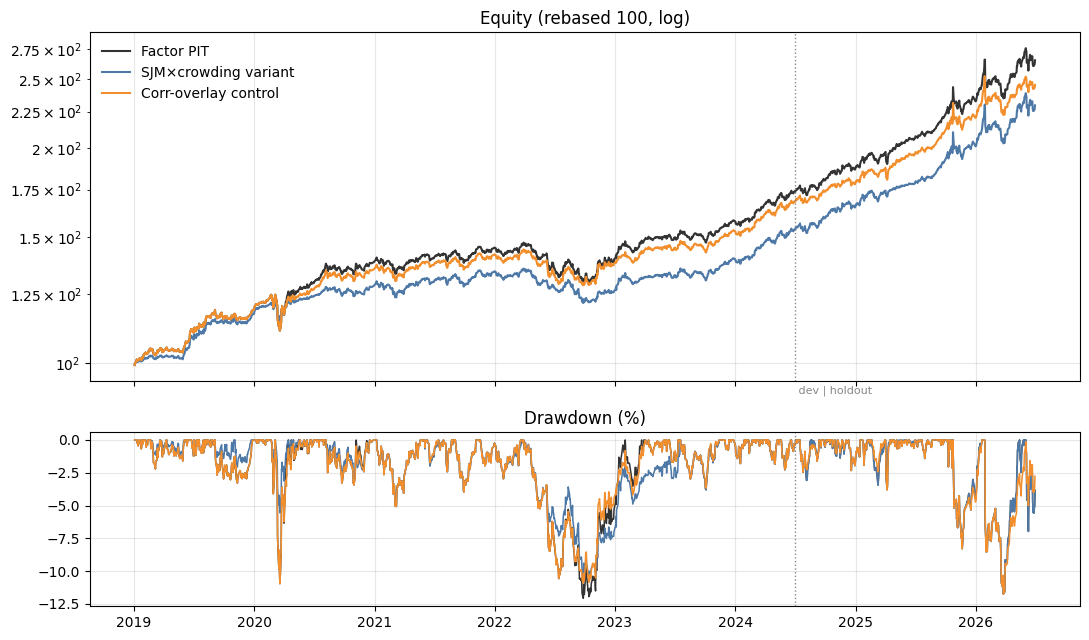

In [8]:
var_ret, var_cap = overlay_returns(BEST_KNOBS)
lines = {"Factor PIT": factor_ret, "SJM×crowding variant": var_ret, "Corr-overlay control": ctrl_ret}
hold = lambda r: r.loc[DEV_END + pd.Timedelta(days=1):]

rows = {}
for name, r in lines.items():
    for tag, seg in (("dev", dev(r)), ("holdout", hold(r)), ("full", r)):
        e = equity_of(seg)
        rows[(name, tag)] = {"CAGR": cagr(e), "maxDD": maxdd(e), "Calmar": calmar(e),
                             "Sharpe": float(seg.mean() / seg.std() * np.sqrt(A))}
summ = pd.DataFrame(rows).T
display(summ.style.format({"CAGR": "{:.2%}", "maxDD": "{:.1%}", "Calmar": "{:.2f}", "Sharpe": "{:.2f}"}))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])
cols = {"Factor PIT": "#333333", "SJM×crowding variant": "#4e79a7", "Corr-overlay control": "#f28e2b"}
for name, r in lines.items():
    e = equity_of(r) * 100
    ax1.plot(e.index, e.values, label=name, color=cols[name], lw=1.5)
    d = equity_of(r); d = d / d.cummax() - 1
    ax2.plot(d.index, d.values * 100, color=cols[name], lw=1.1)
ax1.axvline(DEV_END, color="#888", ls=":", lw=1); ax1.text(DEV_END, ax1.get_ylim()[0], " dev | holdout", fontsize=8, color="#888")
ax2.axvline(DEV_END, color="#888", ls=":", lw=1)
ax1.set_yscale("log"); ax1.legend(frameon=False); ax1.set_title("Equity (rebased 100, log)"); ax1.grid(True, alpha=0.3)
ax2.set_title("Drawdown (%)"); ax2.grid(True, alpha=0.3)
plt.tight_layout();

## 7. Tear sheet (standardized + Paleologo attribution)

In [9]:
def hac_t(r):
    lr, _ = newey_west_var(r.to_numpy())
    return float(r.mean() / np.sqrt(lr / len(r))) if lr > 0 else np.nan

def tear(lines):
    out = {}
    for name, r in lines.items():
        v = equity_of(r)
        var5 = r.quantile(0.05)
        capm = sk.basket_residual(r, spy_ret.to_frame("SPY"), periods_per_year=A)
        bask = sk.basket_residual(r, fac_ret4, periods_per_year=A)
        ma = sk.market_attribution(r, spy_ret, periods_per_year=A)
        out[name] = {
            "Total Return": float(v.iloc[-1] / v.iloc[0] - 1), "CAGR": cagr(v),
            "Ann. Volatility": float(r.std() * np.sqrt(A)), "Sharpe": float(r.mean() / r.std() * np.sqrt(A)),
            "Max Drawdown": maxdd(v), "Calmar": calmar(v),
            "VaR 95 (daily)": float(var5), "CVaR 95 (daily)": float(r[r <= var5].mean()),
            "Excess Kurtosis": float(r.kurtosis()), "Hit Rate": float((r > 0).mean()),
            "SSR (Sharpe Stability)": float(compute_ssr(r).ssr), "HAC t (mean, NW)": hac_t(r),
            "Beta (SPY)": float(ma.beta), "CAPM alpha (ann.)": float(capm.alpha_ann), "CAPM R2": float(capm.r2),
            "Basket R2 (4-ETF)": float(bask.r2), "Basket alpha (ann.)": float(bask.alpha_ann),
            "Basket appraisal (a/se)": float(bask.appraisal) if bask.appraisal is not None else np.nan,
            "Basket t(alpha) HAC": float(bask.t_alpha_hac),
        }
    return pd.DataFrame(out)

_PCT = {"Total Return", "CAGR", "Ann. Volatility", "Max Drawdown", "VaR 95 (daily)", "CVaR 95 (daily)",
        "Hit Rate", "CAPM alpha (ann.)", "Basket alpha (ann.)"}
sheet = tear(lines)
sheet.to_csv(REPORTS / "nb17_sjm_crowding_tearsheet.csv", float_format="%.6f")
display(pd.DataFrame({c: [f"{sheet.loc[m, c]*100:.1f}%" if m in _PCT else f"{sheet.loc[m, c]:.2f}"
                         for m in sheet.index] for c in sheet.columns}, index=sheet.index))
print("wrote", (REPORTS / "nb17_sjm_crowding_tearsheet.csv").name)

,Factor PIT,SJM×crowding variant,Corr-overlay control
Total Return,167.2%,130.3%,146.8%
CAGR,14.0%,11.8%,12.8%
Ann. Volatility,9.7%,8.4%,9.1%
Sharpe,1.43,1.39,1.39
Max Drawdown,-12.1%,-11.8%,-11.8%
Calmar,1.16,1.00,1.09
VaR 95 (daily),-0.8%,-0.7%,-0.8%
CVaR 95 (daily),-1.4%,-1.2%,-1.3%
Excess Kurtosis,19.71,29.81,23.99
Hit Rate,57.1%,56.9%,57.1%


wrote nb17_sjm_crowding_tearsheet.csv


## 8. Notes & honesty box

- **Crowding is proxied, not observed.** Absorption ratio / turbulence measure return-space concentration; true crowding data (CFTC COT positioning, short interest, 13F overlap, ETF flows — the `fmp_etf_holdings` table is a future source) would strengthen the signal.
- **Application is monthly and de-risk-only** (caps ≤ 1, floor ≥ 0.3-0.5); turnover added by the overlay is small, costs are not modeled.
- **PIT discipline held everywhere:** SJM refit walk-forward per rebalance; crowding buckets use expanding quantiles; the AI limit table saw only anonymized dev-window statistics; the loop tuned only on dev; the holdout was evaluated exactly once, after the loop finished.
- The AI's role is **calibration** (one offline table), the runtime is a **deterministic macro-limit function** — exactly the division of labor the user specified, and consistent with the facdrone evidence that regime models earn their keep as de-risk scales, not return-seekers.